<a href="https://colab.research.google.com/github/HemanthIlluri/Customer_Churn_Prediction/blob/main/HemanthIlluri/Customer_Churn_Prediction/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer** **Churn**

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/Customer_Churn.csv")
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())
df.isna().sum()
object_cols = df.select_dtypes(include="object").columns
df[object_cols]=(df[object_cols]
                 .apply(lambda col:col.str.strip())
                 .replace("",np.nan)
)
df.isna().sum()
for col in object_cols:
    print(col)
    print(df[col].unique())
    print()
numeric_cols=df.select_dtypes(include=np.number).columns
df[numeric_cols].describe()
df["ExpectedCharges"] = df["tenure"] * df["MonthlyCharges"]
df[["tenure", "MonthlyCharges", "TotalCharges","ExpectedCharges"]].sort_values(
    "TotalCharges",
    ascending=False
).head(20)
print(df["customerID"].duplicated().sum())
print(df["Churn"].value_counts(normalize=True) * 100)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn
['No' 'Yes']

0
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


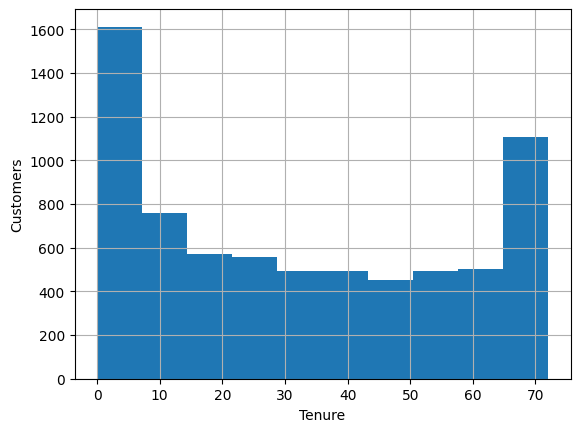

In [2]:
import matplotlib.pyplot as plt

df["tenure"].hist()
plt.xlabel("Tenure")
plt.ylabel("Customers")
plt.show()

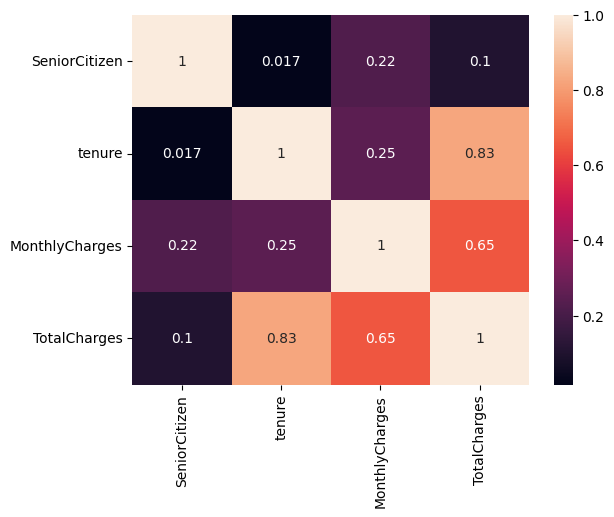

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True
)

plt.show()

In [4]:
print(df.groupby("Churn")["tenure"].mean())
print(df.groupby("Churn")["MonthlyCharges"].mean())
print(df.groupby("Churn")["TotalCharges"].mean())
print(df.groupby("Churn")["SeniorCitizen"].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64
Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64
Churn
No     0.128721
Yes    0.254682
Name: SeniorCitizen, dtype: float64


In [5]:
print(pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100)
print(pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100)
print(pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100)
print(pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100)


Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


In [6]:
for col in object_cols:
  print(f"\n===== {col} =====")
  print(pd.crosstab(
    df[col],
    df["Churn"],
    normalize="index"
) * 100)


===== customerID =====
Churn          No    Yes
customerID              
0002-ORFBO  100.0    0.0
0003-MKNFE  100.0    0.0
0004-TLHLJ    0.0  100.0
0011-IGKFF    0.0  100.0
0013-EXCHZ    0.0  100.0
...           ...    ...
9987-LUTYD  100.0    0.0
9992-RRAMN    0.0  100.0
9992-UJOEL  100.0    0.0
9993-LHIEB  100.0    0.0
9995-HOTOH  100.0    0.0

[7043 rows x 2 columns]

===== gender =====
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

===== Partner =====
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

===== Dependents =====
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

===== PhoneService =====
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

===== MultipleLines =====


In [7]:
df_original = df.copy()
drop_columns = [
    "customerID",   # ID column
    "Churn",        # Target column
    "gender",       # Weak feature from EDA
    "PhoneService"  # Weak feature from EDA
]
X = df.drop(columns=drop_columns)
y = df["Churn"]
print(X.columns)
print("\nNumber of features:")
print(X.shape[1])

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'ExpectedCharges'],
      dtype='object')

Number of features:
18


In [8]:
categorical_columns=X.select_dtypes(include=["object"]).columns
print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical columns:
Index(['Partner', 'Dependents', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod'],
      dtype='object')


In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train_processed,y_train)
y_pred = model.predict(X_test_processed)


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPrecision:")
print(precision_score(y_test, y_pred, pos_label="Yes"))

print("\nRecall:")
print(recall_score(y_test, y_pred, pos_label="Yes"))

print("\nF1 Score:")
print(f1_score(y_test, y_pred, pos_label="Yes"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.8055358410220014

Precision:
0.6572327044025157

Recall:
0.5588235294117647

F1 Score:
0.6040462427745664

Confusion Matrix:
[[926 109]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [16]:
X_train_rf = rf_preprocessor.fit_transform(X_train)

X_test_rf = rf_preprocessor.transform(X_test)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf_model_balanced.fit(X_train_rf, y_train)

y_pred_rf_balanced = rf_model_balanced.predict(X_test_rf)

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_rf_balanced))

print("\nPrecision:")
print(precision_score(y_test, y_pred_rf_balanced, pos_label="Yes"))

print("\nRecall:")
print(recall_score(y_test, y_pred_rf_balanced, pos_label="Yes"))

print("\nF1 Score:")
print(f1_score(y_test, y_pred_rf_balanced, pos_label="Yes"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_balanced))

Accuracy:
0.7665010645848119

Precision:
0.5458248472505092

Recall:
0.7165775401069518

F1 Score:
0.6196531791907515

Confusion Matrix:
[[812 223]
 [106 268]]

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.78      0.83      1035
         Yes       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

